## 1. Setup

In [1]:
import json
import sys
from pathlib import Path
import joblib

import pandas as pd
from itables import show

import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from src.data.columns import PATIENT_COL, DIAGNOSIS_COL
from src.data.ml_dataset_specs import UCVA_TARGET

from src.modeling.model_inputs import prepare_train_test_model_inputs
from src.modeling.configs import (
    ElasticNetConfig, 
    ElasticNetSearchConfig,
    StepwiseConfig
)
from src.modeling.model_stability import (
    evaluate_model_stability,
    compare_candidates_by_metric,
    compare_candidates_by_metrics,
    compare_candidates_by_feature_selection,
)
from src.modeling.coefficient_stability import (
    evaluate_coefficient_stability,
    get_coefficient_stability_view,
)
from src.modeling.pipelines import (
    make_dummy_pipeline,
    make_linear_pipeline,
    make_elasticnet_pipeline,
    make_elasticnetcv_pipeline,
    make_elasticnetselector_linear_pipeline,
    make_stepwise_linear_pipeline,
    make_elasticnetselector_elasticnet_pipeline,
    make_log_target_pipeline,
    make_log10_target_pipeline,
)


DATA_PATH = PROJECT_ROOT / "data" / "ml" / "ucva_exam1_base_2024-11-02.xlsx"
STABILITY_RESULTS_PATH = PROJECT_ROOT / "artifacts" / "model_selection" / "stability_results.joblib"
FINAL_CANDIDATES_PATH = PROJECT_ROOT / "artifacts" / "model_selection" / "final_candidates.json"

VAL_SIZE = 0.2
RANDOM_STATE = 42
N_SPLITS = 100

## 2. Train/Test Data Preparation

In [2]:
df = pd.read_excel(DATA_PATH)
df.shape

(399, 80)

In [3]:
inputs = prepare_train_test_model_inputs(
    df=df,
    target_col=UCVA_TARGET,
    group_col=PATIENT_COL,
    exclude_feature_cols=[DIAGNOSIS_COL],
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
)

train_inputs = inputs.train
test_inputs = inputs.test

train_inputs.X.shape, test_inputs.X.shape

((319, 77), (80, 77))

## 3. Candidate Models

In [4]:
candidate_models = {}

In [5]:
candidate_models["Dummy_mean"] = {
        "estimator": make_dummy_pipeline(strategy="mean"),
    }

candidate_models["Dummy_median"] = {
        "estimator": make_dummy_pipeline(strategy="median"),
    }

In [7]:
candidate_params = [
    #alpha, l1
    # best candidates for MAE
    (0.20, 0.20),
    (0.30, 0.10),
    (0.35, 0.10),
    (0.40, 0.10),
    # best candidates for R2
    (0.20, 0.10),
]

for alpha, l1_ratio in candidate_params:
    config = ElasticNetConfig(
        alpha=alpha,
        l1_ratio=l1_ratio,
    )

    # candidate_name = f"EN_alpha_{alpha:g}_l1_{l1_ratio:g}"
    # candidate_models[candidate_name] = {
    #     "estimator": make_elasticnet_pipeline(config),
    #     "collect_feature_selection": True,
    #     "treat_sparse_model_as_selector": True,
    # }

#     candidate_name = f"ENSelector_LR_alpha_{alpha:g}_l1_{l1_ratio:g}"
#     candidate_models[candidate_name] = {
#         "estimator": make_elasticnetselector_linear_pipeline(config),
#         "collect_feature_selection": True,
#     }

    candidate_name = f"ENSelector_EN_alpha_{alpha:g}_l1_{l1_ratio:g}"
    candidate_models[candidate_name] = {
        "estimator": make_elasticnetselector_elasticnet_pipeline(config, config),
        "collect_feature_selection": True,
        "treat_sparse_model_as_selector": True,
    }

In [ ]:
# candidate_models["ENCV"] = {
#         "estimator": make_elasticnetcv_pipeline(
#             elasticnet_search = ElasticNetSearchConfig(
#                 alphas=np.linspace(0.01, 0.09, 9),
#                 l1_ratios=np.linspace(0.05, 0.5, 19),
#             ),
#             n_splits=5,
#             random_state=42,
#         ),
#         "collect_feature_selection": True,
#         "treat_sparse_model_as_selector": True,
#     }

In [8]:
# candidate_models["Stepwise_LR"] = {
#     "estimator": make_stepwise_linear_pipeline(
#         stepwise = StepwiseConfig(),
#     ),
#     "collect_feature_selection": True,
# }

candidate_models["Stepwise_LR_log"] = {
    "estimator": make_log_target_pipeline(
        make_stepwise_linear_pipeline(
            stepwise=StepwiseConfig(),
        )
    ),
    "collect_feature_selection": True,
}

## 4. Model Stability Evaluation

In [9]:
stability_results = {}

for candidate_name, candidate in candidate_models.items():
    stability_results[candidate_name] = evaluate_model_stability(
        estimator=candidate["estimator"],
        X=train_inputs.X,
        y=train_inputs.y,
        groups=train_inputs.groups,
        n_splits=100,
        val_size=0.2,
        random_state=RANDOM_STATE,
        collect_feature_selection=candidate.get("collect_feature_selection", True),
        treat_sparse_model_as_selector=candidate.get("treat_sparse_model_as_selector", False),
    )

    STABILITY_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True) 
    joblib.dump(stability_results, STABILITY_RESULTS_PATH)

## 5. Metric Comparison

In [10]:
mae_comparison = compare_candidates_by_metric(
    stability_results=stability_results,
    metric="mae",
    lower_is_better=True,
)

show(mae_comparison, pageLength=25)

Loading ITables v2.7.3 from the internet... (need help?)


In [11]:
r2_comparison = compare_candidates_by_metric(
    stability_results=stability_results,
    metric="r2",
    lower_is_better=False,
)

show(r2_comparison, pageLength=25)

Loading ITables v2.7.3 from the internet... (need help?)


In [12]:
rmse_comparison = compare_candidates_by_metric(
    stability_results=stability_results,
    metric="rmse",
    lower_is_better=True,
)

show(rmse_comparison, pageLength=25)

Loading ITables v2.7.3 from the internet... (need help?)


In [13]:
final_comparison = compare_candidates_by_metrics(stability_results)
show(final_comparison, pageLength=25)

Loading ITables v2.7.3 from the internet... (need help?)


## 6. Metric Variability Analysis

### 6.1. Metric distribution analysis

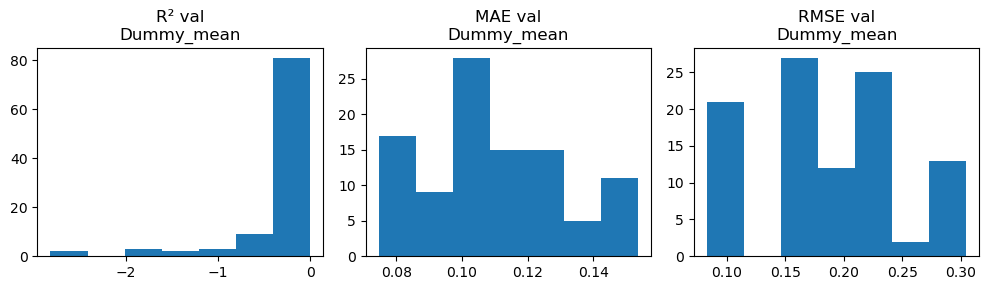

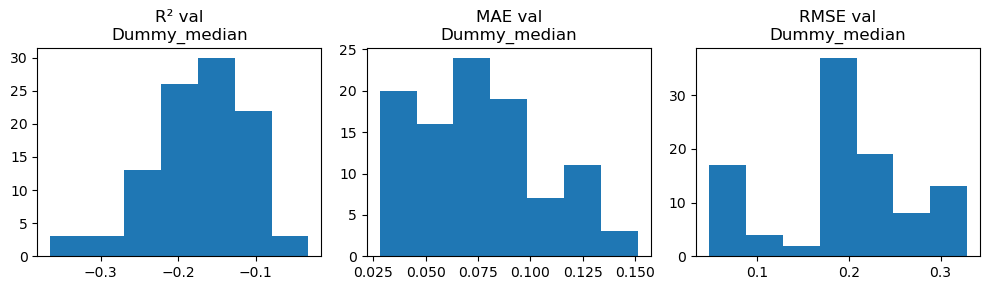

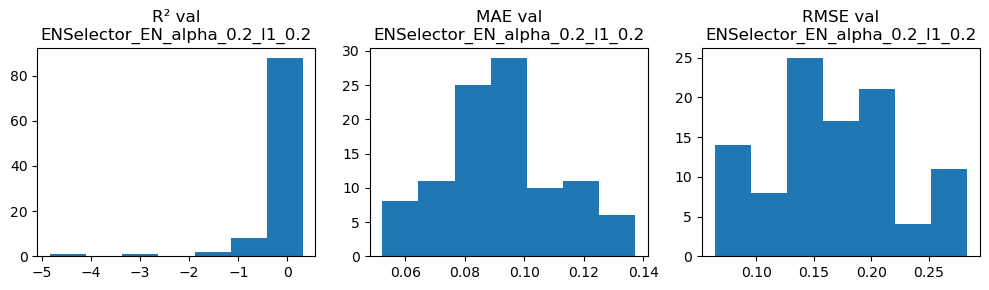

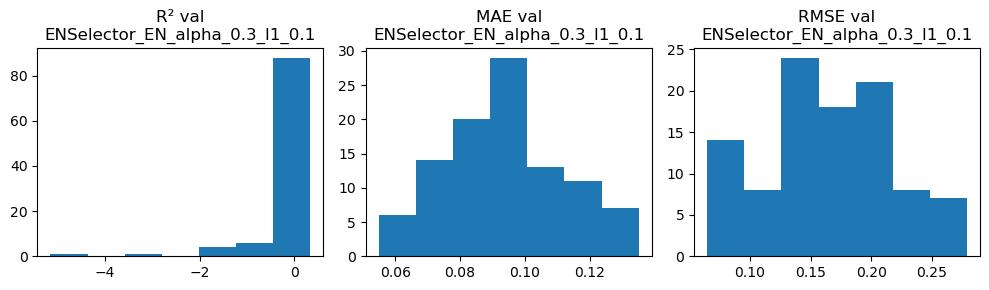

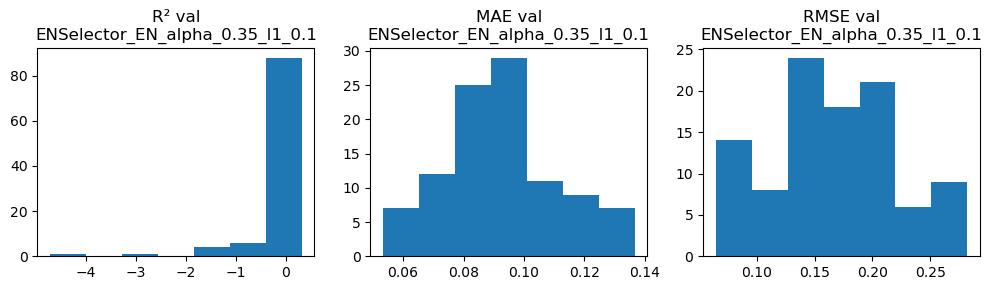

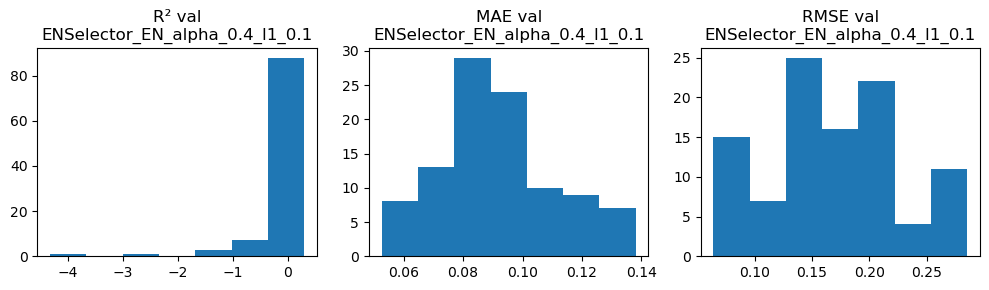

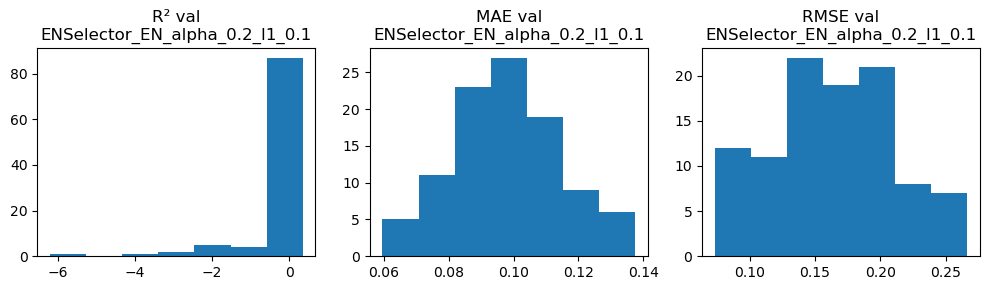

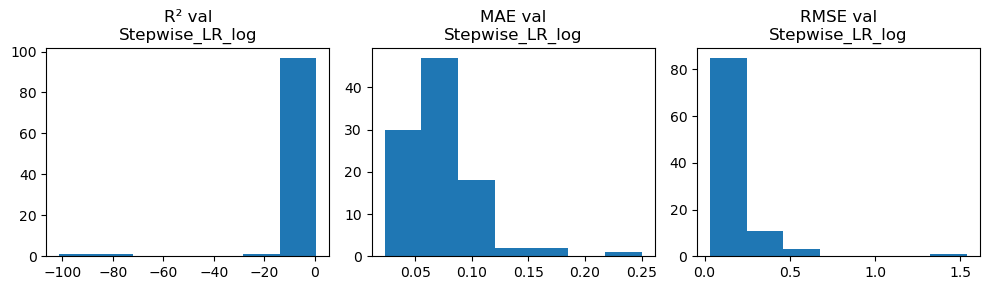

In [14]:
for candidate_name, stability in stability_results.items():
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    bins = 7
    
    axes[0].hist(stability.scores["r2_val"], bins=bins)
    axes[0].set_title(f"R² val\n{candidate_name}")

    axes[1].hist(stability.scores["mae_val"], bins=bins)
    axes[1].set_title(f"MAE val\n{candidate_name}")

    axes[2].hist(stability.scores["rmse_val"], bins=bins)
    axes[2].set_title(f"RMSE val\n{candidate_name}")

    plt.tight_layout()
    plt.show()

### 6.2. R2 variability analysis

In [19]:
candidate_name = "ENSelector_EN_alpha_0.35_l1_0.1"
# candidate_name = "Stepwise_LR_log"
selected_stability_results = stability_results[candidate_name]

In [20]:
from collections import Counter

worst_splits = (
    selected_stability_results
    .scores
    .sort_values("r2_val")
)

print("Worst splits")
display(worst_splits[["r2_val", "target_std_val", "target_range_val"]].head(10))

print("Best splits")
display(worst_splits[["r2_val", "target_std_val", "target_range_val"]].tail(10))

worst_groups = worst_splits["groups_val"]

# Перетин пацієнтів, які є в усіх worst splits
common_worst_patients = set(worst_groups.iloc[0])

for groups in worst_groups.iloc[1:]:
    common_worst_patients &= set(groups)

print(f"Перетин пацієнтів: {common_worst_patients}")

# Частоти появи пацієнтів у worst splits
patient_counter = Counter()

for groups in worst_groups:
    patient_counter.update(groups)

worst_patient_frequencies = (
    pd.DataFrame(
        patient_counter.items(),
        columns=["patient_id", "n_worst_splits"],
    )
    .sort_values("n_worst_splits", ascending=False)
)

worst_patient_frequencies["frequency"] = worst_patient_frequencies["n_worst_splits"] / len(worst_splits)

worst_patient_frequencies.head(10)

Worst splits


,r2_val,target_std_val,target_range_val
84,-4.708387,0.043460,0.17
8,-2.808611,0.050998,0.28
6,-1.639428,0.052616,0.19
15,-1.188691,0.058185,0.28
0,-1.159264,0.055161,0.29
35,-1.141131,0.051636,0.18
42,-1.010044,0.061386,0.28
37,-0.989605,0.063731,0.28
18,-0.969763,0.046764,0.18
79,-0.704470,0.063533,0.37


Best splits


,r2_val,target_std_val,target_range_val
38,0.257543,0.176392,0.98
70,0.266234,0.172012,0.99
2,0.268834,0.177697,0.98
10,0.270482,0.187519,0.98
97,0.276587,0.179947,0.98
71,0.282216,0.165812,0.97
50,0.283074,0.175109,0.99
80,0.305312,0.168412,0.99
51,0.318361,0.163099,0.89
3,0.322474,0.149888,0.88


Перетин пацієнтів: set()


,patient_id,n_worst_splits,frequency
98,12,30,0.30
39,86,29,0.29
56,188,29,0.29
0,5,28,0.28
63,65,28,0.28
27,176,28,0.28
107,198,28,0.28
64,112,27,0.27
32,7,27,0.27
45,104,27,0.27


In [21]:
def show_r2_vs_target_std(scores, ax, title):
    pearson_corr = scores[["r2_val", "target_std_val"]].corr(method="pearson").iloc[0, 1]
    spearman_corr = scores[["r2_val", "target_std_val"]].corr(method="spearman").iloc[0, 1]

    ax.scatter(scores["target_std_val"], scores["r2_val"])

    ax.axhline(0, linestyle="--")

    ax.set_xlabel("target std val")
    ax.set_ylabel("R² val")
    ax.set_title(
        f"{title}\n"
        f"Pearson = {pearson_corr:.3f}\n"
        f"Spearman = {spearman_corr:.3f}"
    )

    plt.grid(True)

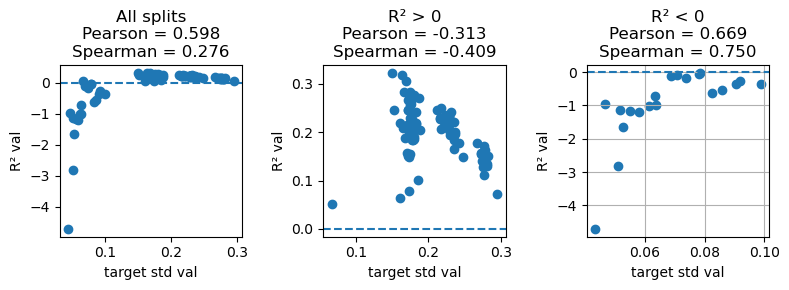

In [22]:
scores = selected_stability_results.scores

positive_scores = scores[scores["r2_val"] > 0]
negative_scores = scores[scores["r2_val"] < 0]

fig, axes = plt.subplots(1, 3, figsize=(8, 3))

show_r2_vs_target_std(scores, ax=axes[0], title="All splits")
show_r2_vs_target_std(positive_scores, ax=axes[1], title="R² > 0")
show_r2_vs_target_std(negative_scores, ax=axes[2], title="R² < 0")

plt.tight_layout()

plt.show()


**Для моделей ElasticNet** метрики MAE та RMSE демонструють відносно компактний та стабільний розподіл між різними val-розбиттями без виражених екстремальних значень. Натомість метрика R² характеризується значно більшою варіативністю: у частині розбиттів вона набуває від’ємних значень. Аналіз показав, що така нестабільність R² не пов’язана з наявністю окремих аномальних пацієнтів. Імовірно, причиною є малий розкид цільової ознаки в деяких val-розбиттях. У таких випадках метрика R² стає дуже чутливою навіть до помірних похибок прогнозування. Тому в даному дослідженні доцільно розглядати MAE та RMSE як більш стабільні показники якості моделі.  
**Для моделі Linear Regression with Stepwise Selector** нестабільна поведінка  спостергіається не лише для метрики R², а й для MAE та RMSE. MAE та RMSE характеризуються асиметричними розподілами з довгими правими хвостами, що свідчить про наявність окремих розбиттів із суттєвим погіршенням якості прогнозування. Метрика R² демонструє ще більш виражену нестаібльність, ніж у моделях ElasticNet: у частині val-розбиттів вона набуває значень близько -18, -80 та -100. На відміну від ElasticNet, де нестабільність R² могла пояснюватися малим розкидом цільової ознаки у деяких вибірках, у даному випадку, ймовірно, є й інша принина. Можливо, модель є чутливою до конкретного складу навчальної вибірки. Потрібний додатковий аналіз.

## 7. Feature Selection Comparison

In [23]:
feature_selection_comparison = compare_candidates_by_feature_selection(stability_results)
show(feature_selection_comparison)

Loading ITables v2.7.3 from the internet... (need help?)


Feature × split matrix для одного кандидата  
Залишаємо тільки ознаки, які хоча б іноді входили в модель

In [31]:
candidate_name = "ENSelector_EN_alpha_0.35_l1_0.1"
# candidate_name = "Stepwise_LR_log"

feature_selection = stability_results[candidate_name].feature_selection

feature_matrix = (
    feature_selection
    .pivot(
        index="feature",
        columns="split_id",
        values="selected",
    )
)

feature_matrix.columns = [
    f"split_{col}"
    for col in feature_matrix.columns
]

feature_matrix["selection_frequency"] = feature_matrix.mean(axis=1)

feature_matrix = feature_matrix.sort_values(
    "selection_frequency",
    ascending=False,
)

selected_feature_matrix = (
    feature_matrix
    .query("selection_frequency > 0")
    .copy()
)

show(selected_feature_matrix)

Loading ITables v2.7.3 from the internet... (need help?)


Кореляція патернів входження ознак

In [32]:
feature_matrix_numeric = (
    selected_feature_matrix
    .drop(columns="selection_frequency")
    .astype(int)
)

selection_corr = feature_matrix_numeric.T.corr()

show(selection_corr)

Loading ITables v2.7.3 from the internet... (need help?)


Пари ознак, які часто входять разом

In [33]:
together_pairs = []

for i, feature_1 in enumerate(features):
    for feature_2 in features[i + 1:]:
        corr = selection_corr.loc[feature_1, feature_2]

        if corr > 0.5:
            together_pairs.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "selection_corr": corr,
                "selection_frequency_1": selected_feature_matrix.loc[
                    feature_1,
                    "selection_frequency",
                ],
                "selection_frequency_2": selected_feature_matrix.loc[
                    feature_2,
                    "selection_frequency",
                ],
            })

if together_pairs:
    features_selected_together = (
        pd.DataFrame(together_pairs)
        .sort_values("selection_corr", ascending=False)
    )
else:
    features_selected_together = pd.DataFrame(
        columns=[
            "feature_1",
            "feature_2",
            "selection_corr",
            "selection_frequency_1",
            "selection_frequency_2",
        ]
    )

show(features_selected_together)

Loading ITables v2.7.3 from the internet... (need help?)


## 8. Coefficient Stability Analysis for Selected Candidate

In [29]:
# candidate_name = "ENSelector_EN_alpha_0.35_l1_0.1"
candidate_name = "Stepwise_LR_log"

model = candidate_models[candidate_name]["estimator"]

coef_stability = evaluate_coefficient_stability(
    estimator=model,
    X=train_inputs.X,
    y=train_inputs.y,
    groups=train_inputs.groups,
    n_splits=N_SPLITS,
    val_size=0.2,
    random_state=RANDOM_STATE,
)

In [34]:
coef_stability_view = get_coefficient_stability_view(coef_stability, mode="in_model")
show(coef_stability_view)

Loading ITables v2.7.3 from the internet... (need help?)


## 9. Final Candidates Selection and Saving

In [35]:
top_stepwise_features = (
    stability_results["Stepwise_LR_log"]
    .feature_selection_summary
    .sort_values("selection_frequency", ascending=False)
    .head(10)["feature"]
    .tolist()
)
top_stepwise_features.remove("вертикальний 6")
top_stepwise_features

['Рефрактометрія циклоплегія Sphera',
 'Рефрактометрія циклоплегія Cylynder',
 'Axial length (mm)',
 'Вік',
 'Кератометрія циклоплегії Cyl',
 'Рефрактометрія без циклоплегії Sphera',
 'Pupil diameter (mm)',
 'Стать: 1 - ч, 2 - ж',
 'Flat meridian K1 (D)']

In [36]:
top_elasticnet_features = (
    stability_results["ENSelector_EN_alpha_0.35_l1_0.1"]
    .feature_selection_summary
    .sort_values("selection_frequency", ascending=False)
    .head(6)["feature"]
    .tolist()
)
top_elasticnet_features

['Axial length (mm)',
 'Рефрактометрія без циклоплегії Sphera',
 'Рефрактометрія циклоплегія Sphera',
 'Рефрактометрія циклоплегія Cylynder',
 'A. C. Depth (mm)',
 'Вік']

In [37]:
final_candidates = {
    "Dummy_median": {
        "pipeline_factory": "make_dummy_pipeline",
        "params": {"strategy": "median"},
        "features": "all",
    },

    "ENSelector_EN_alpha_0.35_l1_0.1": {
        "pipeline_factory": "make_elasticnet_pipeline",
        "params": {"alpha": 0.35, "l1_ratio": 0.1},
        "features": list(top_elasticnet_features),
    },

    "Stepwise_LR_log": {
        "pipeline_factory": "make_log_target_pipeline(make_linear_pipeline)",
        "params": {},
        "features": list(top_stepwise_features),
    },
}

In [38]:
FINAL_CANDIDATES_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(FINAL_CANDIDATES_PATH, "w", encoding="utf-8") as f:
    json.dump(final_candidates, f, ensure_ascii=False, indent=4)